<a href="https://colab.research.google.com/github/hamshini1413/deep-learning/blob/main/4_Custom_Gradient_Descent_Optimizers_with_Momentum%2C_RMSprop%2C_and_Adam_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

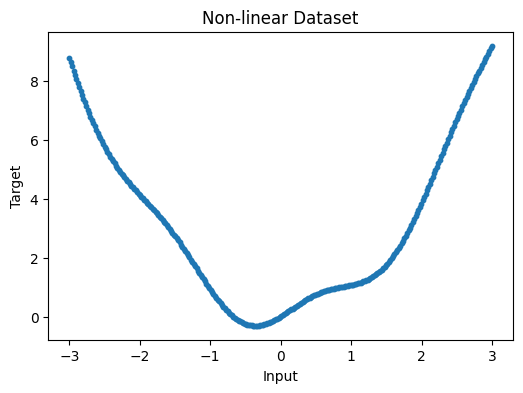

In [2]:
# Non-linear dataset

X = torch.linspace(-3, 3, 300).reshape(-1,1)

Y = X**2 + 0.5*torch.sin(3*X)

plt.figure(figsize=(6,4))
plt.scatter(X.numpy(), Y.numpy(), s=10)
plt.title("Non-linear Dataset")
plt.xlabel("Input")
plt.ylabel("Target")
plt.show()

In [3]:
input_size = 1
hidden_size = 16
output_size = 1

# Xavier Initialization
W1 = torch.randn(input_size, hidden_size) * (2/(input_size+hidden_size))**0.5
b1 = torch.zeros(hidden_size)

W2 = torch.randn(hidden_size, output_size) * (2/(hidden_size+output_size))**0.5
b2 = torch.zeros(output_size)

In [4]:
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

def relu_grad(x):
    return (x>0).float()

def forward(x):

    z1 = x @ W1 + b1

    a1 = relu(z1)

    out = a1 @ W2 + b2

    return z1,a1,out

In [5]:
def backward(x,y,z1,a1,out):

    m = len(x)

    d_out = 2*(out-y)/m

    dW2 = a1.t() @ d_out

    db2 = d_out.sum(0)

    d_hidden = d_out @ W2.t()

    d_hidden = d_hidden * relu_grad(z1)

    dW1 = x.t() @ d_hidden

    db1 = d_hidden.sum(0)

    return dW1,db1,dW2,db2

In [6]:
optimizer = "adam"
# momentum
# rmsprop
# adam

In [7]:
lr = 0.01
epochs = 500

# Momentum
vW1 = torch.zeros_like(W1)
vb1 = torch.zeros_like(b1)

vW2 = torch.zeros_like(W2)
vb2 = torch.zeros_like(b2)

beta = 0.9

# RMSprop
sW1 = torch.zeros_like(W1)
sb1 = torch.zeros_like(b1)

sW2 = torch.zeros_like(W2)
sb2 = torch.zeros_like(b2)

beta2 = 0.99

# Adam
mW1 = torch.zeros_like(W1)
mb1 = torch.zeros_like(b1)

mW2 = torch.zeros_like(W2)
mb2 = torch.zeros_like(b2)

vW1_adam = torch.zeros_like(W1)
vb1_adam = torch.zeros_like(b1)

vW2_adam = torch.zeros_like(W2)
vb2_adam = torch.zeros_like(b2)

eps = 1e-8

In [8]:
losses=[]

for epoch in range(1,epochs+1):

    z1,a1,out = forward(X)

    loss = torch.mean((out-Y)**2)

    losses.append(loss.item())

    dW1,db1,dW2,db2 = backward(X,Y,z1,a1,out)

    if optimizer=="momentum":

        vW1 = beta*vW1 + lr*dW1
        vb1 = beta*vb1 + lr*db1

        vW2 = beta*vW2 + lr*dW2
        vb2 = beta*vb2 + lr*db2

        W1 -= vW1
        b1 -= vb1

        W2 -= vW2
        b2 -= vb2

    elif optimizer=="rmsprop":

        sW1 = beta2*sW1 + (1-beta2)*(dW1**2)
        sb1 = beta2*sb1 + (1-beta2)*(db1**2)

        sW2 = beta2*sW2 + (1-beta2)*(dW2**2)
        sb2 = beta2*sb2 + (1-beta2)*(db2**2)

        W1 -= lr*dW1/(torch.sqrt(sW1)+eps)
        b1 -= lr*db1/(torch.sqrt(sb1)+eps)

        W2 -= lr*dW2/(torch.sqrt(sW2)+eps)
        b2 -= lr*db2/(torch.sqrt(sb2)+eps)

    elif optimizer=="adam":

        mW1 = beta*mW1 + (1-beta)*dW1
        mb1 = beta*mb1 + (1-beta)*db1

        mW2 = beta*mW2 + (1-beta)*dW2
        mb2 = beta*mb2 + (1-beta)*db2

        vW1_adam = beta2*vW1_adam + (1-beta2)*(dW1**2)
        vb1_adam = beta2*vb1_adam + (1-beta2)*(db1**2)

        vW2_adam = beta2*vW2_adam + (1-beta2)*(dW2**2)
        vb2_adam = beta2*vb2_adam + (1-beta2)*(db2**2)

        mW1_hat = mW1/(1-beta**epoch)
        mb1_hat = mb1/(1-beta**epoch)

        mW2_hat = mW2/(1-beta**epoch)
        mb2_hat = mb2/(1-beta**epoch)

        vW1_hat = vW1_adam/(1-beta2**epoch)
        vb1_hat = vb1_adam/(1-beta2**epoch)

        vW2_hat = vW2_adam/(1-beta2**epoch)
        vb2_hat = vb2_adam/(1-beta2**epoch)

        W1 -= lr*mW1_hat/(torch.sqrt(vW1_hat)+eps)
        b1 -= lr*mb1_hat/(torch.sqrt(vb1_hat)+eps)

        W2 -= lr*mW2_hat/(torch.sqrt(vW2_hat)+eps)
        b2 -= lr*mb2_hat/(torch.sqrt(vb2_hat)+eps)

    if epoch%50==0:

        print(f"Epoch {epoch} Loss {loss.item():.5f}")

Epoch 50 Loss 1.25341
Epoch 100 Loss 0.57453
Epoch 150 Loss 0.34481
Epoch 200 Loss 0.22024
Epoch 250 Loss 0.13336
Epoch 300 Loss 0.08253
Epoch 350 Loss 0.04525
Epoch 400 Loss 0.02435
Epoch 450 Loss 0.01674
Epoch 500 Loss 0.01173


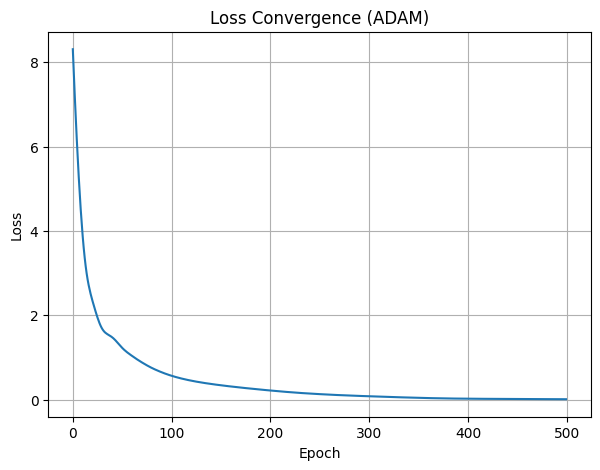

In [9]:
plt.figure(figsize=(7,5))

plt.plot(losses)

plt.title(f"Loss Convergence ({optimizer.upper()})")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

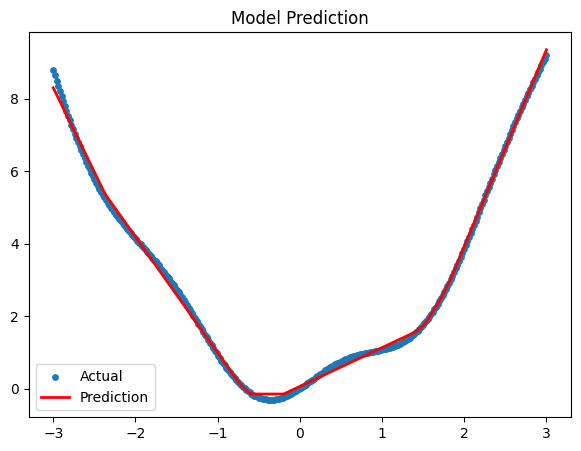

In [10]:
_,_,prediction = forward(X)

plt.figure(figsize=(7,5))

plt.scatter(X.numpy(),Y.numpy(),label="Actual",s=15)

plt.plot(X.numpy(),prediction.detach().numpy(),
         color="red",
         linewidth=2,
         label="Prediction")

plt.legend()

plt.title("Model Prediction")

plt.show()